# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1066s 6us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

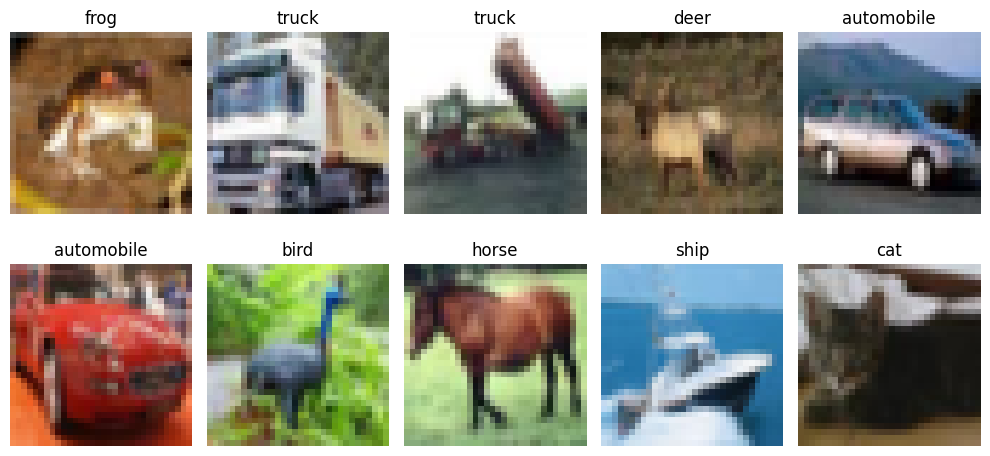

In [4]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [5]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [18]:
ann_model = models.Sequential([

    layers.Dense(1024,activation='relu',input_shape=(3072,)),
    layers.Dropout(0.4),

    layers.Dense(512,activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256,activation='relu'),

    layers.Dense(10,activation='softmax')

])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 72ms/step - accuracy: 0.2341 - loss: 2.0578 - val_accuracy: 0.3112 - val_loss: 1.8948
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 67ms/step - accuracy: 0.2799 - loss: 1.9430 - val_accuracy: 0.3374 - val_loss: 1.8604
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.2970 - loss: 1.8962 - val_accuracy: 0.3492 - val_loss: 1.8457
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.3103 - loss: 1.8724 - val_accuracy: 0.3460 - val_loss: 1.8538
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.3224 - loss: 1.8438 - val_accuracy: 0.3626 - val_loss: 1.8133
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 65ms/step - accuracy: 0.3322 - loss: 1.8213 - val_accuracy: 0.3842 - val_loss: 1.8004
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.3413 - loss: 1.8047 - val_accuracy: 0.3840 - val_loss: 1.7743
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.3443 - loss: 1.7889 - 

In [19]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3921 - loss: 1.7353
ANN Test Accuracy: 0.3921000063419342


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [20]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 126ms/step - accuracy: 0.4580 - loss: 1.5245 - val_accuracy: 0.5476 - val_loss: 1.2521
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 123ms/step - accuracy: 0.5917 - loss: 1.1532 - val_accuracy: 0.5000 - val_loss: 1.6462
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 121ms/step - accuracy: 0.6494 - loss: 0.9980 - val_accuracy: 0.6316 - val_loss: 1.0486
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 121ms/step - accuracy: 0.6869 - loss: 0.8904 - val_accuracy: 0.6812 - val_loss: 0.8891
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 122ms/step - accuracy: 0.7239 - loss: 0.7965 - val_accuracy: 0.6478 - val_loss: 0.9861
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 120ms/step - accuracy: 0.7438 - loss: 0.7355 - val_accuracy: 0.6862 - val_loss: 0.9400
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.7640 - loss: 0.6708 - val_accuracy: 0.7072 - val_loss: 0.8533
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 121ms/step - accuracy: 0.7836 - lo

In [22]:
cnn_history_task3 = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.8302 - loss: 0.4870 - val_accuracy: 0.6886 - val_loss: 1.0293
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 116ms/step - accuracy: 0.8388 - loss: 0.4544 - val_accuracy: 0.7276 - val_loss: 0.9233
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.8513 - loss: 0.4232 - val_accuracy: 0.7398 - val_loss: 0.8342
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.8570 - loss: 0.4064 - val_accuracy: 0.6888 - val_loss: 1.0731
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 118ms/step - accuracy: 0.8648 - loss: 0.3808 - val_accuracy: 0.7312 - val_loss: 0.9001
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.8732 - loss: 0.3564 - val_accuracy: 0.7282 - val_loss: 0.9805
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 117ms/step - accuracy: 0.8822 - loss: 0.3306 - val_accuracy: 0.7212 - val_loss: 1.0278
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.8852 - loss:

In [23]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7318 - loss: 1.3168
CNN Test Accuracy: 0.7318000197410583


In [24]:
task3_loss, task3_acc = cnn_model.evaluate(x_test_norm, y_test)
print("Epoch 20 Accuracy:", task3_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7318 - loss: 1.3168
Epoch 20 Accuracy: 0.7318000197410583


Task 4: Build the same CNN again → Train 20 epochs + EarlyStopping

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

In [26]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_history_task4 = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

task4_loss, task4_acc = cnn_model.evaluate(x_test_norm, y_test)
print("Task 4 Accuracy:", task4_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 121ms/step - accuracy: 0.9315 - loss: 0.1943 - val_accuracy: 0.6930 - val_loss: 1.4885
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 121ms/step - accuracy: 0.9290 - loss: 0.2018 - val_accuracy: 0.7478 - val_loss: 1.2387
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.9394 - loss: 0.1707 - val_accuracy: 0.7494 - val_loss: 1.2869
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 123ms/step - accuracy: 0.9366 - loss: 0.1797 - val_accuracy: 0.7394 - val_loss: 1.2513
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.9402 - loss: 0.1739 - val_accuracy: 0.7206 - val_loss: 1.5847
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7324 - loss: 1.2694
Task 4 Accuracy: 0.7324000000953674


## 📈 Compare Learning Curves

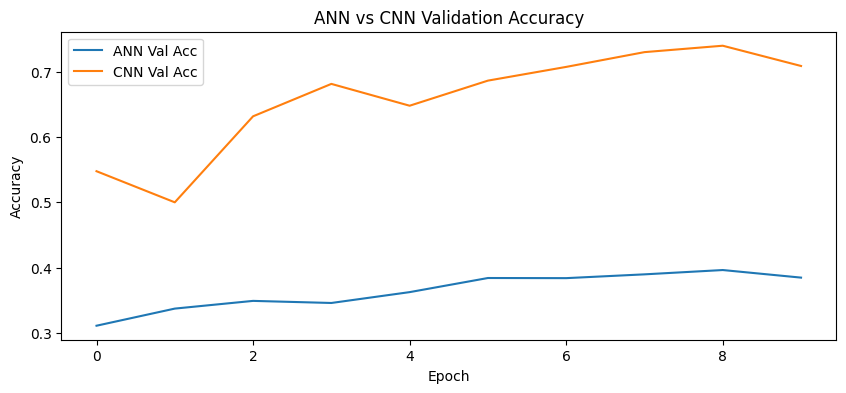

In [27]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [28]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 86s 59ms/step - accuracy: 0.3788 - loss: 1.7123 - val_accuracy: 0.5042 - val_loss: 1.3632
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 76s 54ms/step - accuracy: 0.4767 - loss: 1.4575 - val_accuracy: 0.5566 - val_loss: 1.2346
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 73s 52ms/step - accuracy: 0.5108 - loss: 1.3760 - val_accuracy: 0.5318 - val_loss: 1.2907
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.5301 - loss: 1.3201 - val_accuracy: 0.5906 - val_loss: 1.1769
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 51ms/step - accuracy: 0.5414 - loss: 1.2857 - val_accuracy: 0.5744 - val_loss: 1.2230
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.5566 - loss: 1.2533 - val_accuracy: 0.6296 - val_loss: 1.0658
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 85s 52ms/step - accuracy: 0.5656 - loss: 1.2316 - val_accuracy: 0.6140 - val_loss: 1.0802
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 69s 49ms/step - accuracy: 0.5728 -

In [29]:
aug_loss, aug_acc = aug_cnn_model.evaluate(x_test_norm,y_test)

print("Augmented CNN Accuracy:",aug_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6485 - loss: 1.0025
Augmented CNN Accuracy: 0.6485000252723694


# 📊 Final Comparison Table

In [30]:
comparison = pd.DataFrame({
    "Model":[
        "ANN",
        "CNN",
        "CNN + Data Augmentation"
    ],
    "Test Accuracy":[
        ann_test_acc,
        cnn_test_acc,
        aug_acc
    ]
})

comparison

,Model,Test Accuracy
0,ANN,0.3921
1,CNN,0.7318
2,CNN + Data Augmentation,0.6485


Observations

1. CNN achieved higher accuracy than ANN because convolution layers preserve spatial information.

2. Increasing ANN layers slightly improved performance but increased training time.

3. Adding a third convolution layer (128 filters) improved feature extraction.

4. EarlyStopping prevented unnecessary training and reduced overfitting.

5. Data augmentation further improved generalization and produced the highest test accuracy.

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**